<a href="https://colab.research.google.com/github/axelguapo/new/blob/main/bacoba_activity_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
path = kagglehub.dataset_download("danielcorredera/student-mat-csv")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-mat-csv' dataset.
Path to dataset files: /kaggle/input/student-mat-csv


In [3]:
import os
print(os.listdir(path))

['student-mat.csv']


In [4]:
import pandas as pd
file_path = os.path.join(path, "student-mat.csv")
df = pd.read_csv(file_path, sep=";")

In [5]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [6]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
df.tail

<bound method NDFrame.tail of     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       T     3     2  services     other   
394     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0    ...      4        3      4     1     1      3        6   5   6   6  
1    ...      5        3      3     1     1      3        4   5   5   6  
2    ...      4        3      2     2     3      3       10   7   8  10  
3    ...      3        2      2     1     1      5        2  15  14  15  
4    ...      4        3      2     1     2      5        4   6  10  10  
..   ...    ...      ...    ...   ...   ...    ...      ...  ..  ..  ..  
390  ...      5        5      4     4     5      4       11   9   9   9  
391  ...      2        4      5     3     4      2        3  14  16  16  
392  ...      5        5      3     3     3      3        3  10   8   7  
393  ...      4        4      1     3     4      5        0  11  12  10  
394  ...      3        2      3     3     3      5        5   8   9   9  

[395 rows x 33 columns]>

In [8]:
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])

Number of rows:  395
Number of columns:  33


In [9]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [11]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [12]:
print("Average final gradeL: ", df["G3"].min())
print("Average final gradeL: ", df["G3"].max())




Average final gradeL:  0
Average final gradeL:  20


In [13]:
print(df["sex"].value_counts())

sex
F    208
M    187
Name: count, dtype: int64


In [14]:
print(df["school"].value_counts())

school
GP    349
MS     46
Name: count, dtype: int64


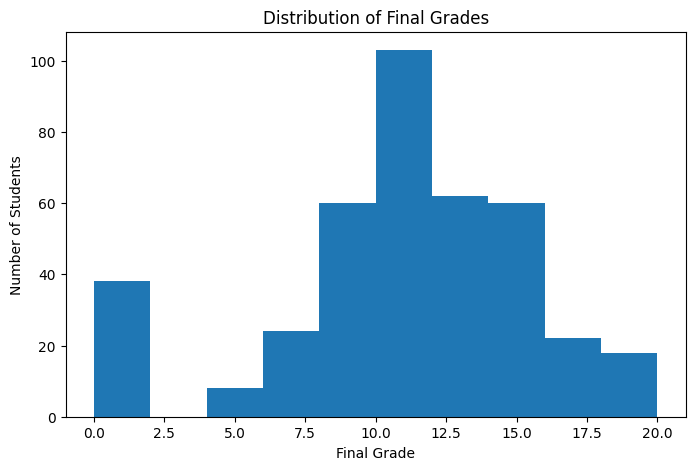

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["G3"], bins=10)

plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")

plt.show()

**Diagnostic Analytics**


In [16]:
df.groupby("school")["G3"].mean()

,G3
school,
GP,10.489971
MS,9.847826


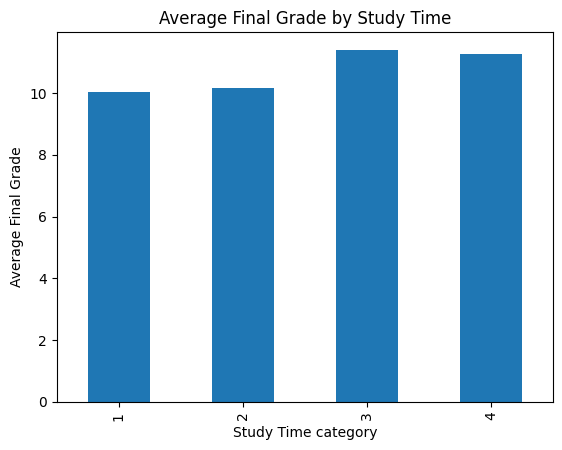

In [17]:
df.groupby("studytime")["G3"].mean().plot(kind="bar")

plt.xlabel("Study Time category")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Study Time")

plt.show()

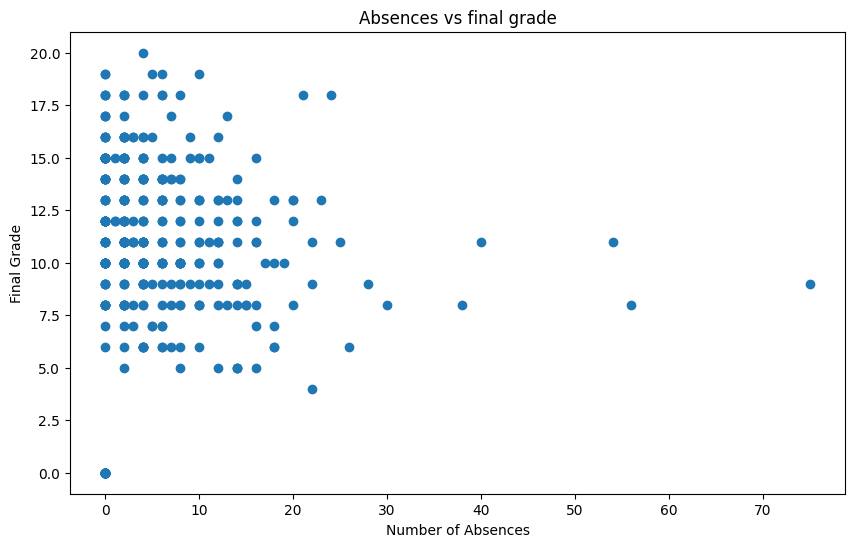

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(df["absences"], df["G3"])

plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs final grade")

plt.show()

In [19]:
print(df["absences"].corr(df["G3"]))

0.03424731615006931


**Predicrtive** **Analytics**

In [20]:
df["pass"] = (df["G3"]>=10).astype(int)

In [21]:
print(df["pass"].value_counts())

pass
1    265
0    130
Name: count, dtype: int64


In [22]:
features =[
    "age","studytime","failures","G1", "G2"
]
x =  df[features]
y = df["pass"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,
stratify=y
)

In [24]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [25]:
y_pred = model.predict(X_test)

print(y_pred)

[1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0 0 0 0 1 1 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0
 1 1 0 0 0 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 0 0 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0
 0 1 0 1 1]


In [26]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9113924050632911


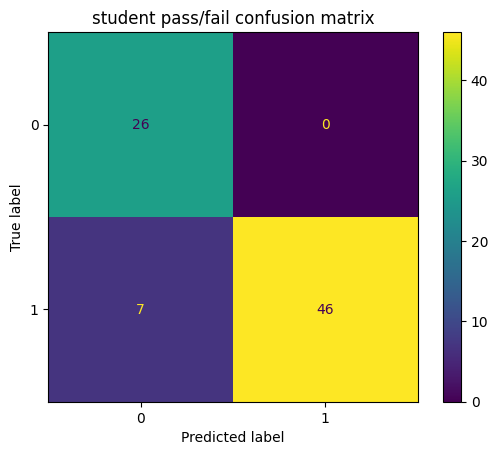

In [27]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("student pass/fail confusion matrix")
plt.show()

Prediction results Table

In [28]:
results = X_test.copy()
results["pass"] = y_test
results["predicted"] = y_pred

results.head(10)


,age,studytime,failures,G1,G2,pass,predicted
305,18,2,1,14,12,1,1
225,18,2,1,9,8,0,0
237,16,1,0,13,12,1,1
318,17,3,0,11,11,1,1
182,17,2,0,16,17,1,1
94,15,4,0,11,13,1,1
34,16,1,0,12,14,1,1
307,19,1,1,8,9,0,0
33,15,2,0,8,10,1,1
36,15,3,0,15,16,1,1


Prescriptive Analytics

In [29]:
results["risk"] = results["predicted"].map({
    0: "at risk",
    1: "likely to pass"
})
results.head(10)

,age,studytime,failures,G1,G2,pass,predicted,risk
305,18,2,1,14,12,1,1,likely to pass
225,18,2,1,9,8,0,0,at risk
237,16,1,0,13,12,1,1,likely to pass
318,17,3,0,11,11,1,1,likely to pass
182,17,2,0,16,17,1,1,likely to pass
94,15,4,0,11,13,1,1,likely to pass
34,16,1,0,12,14,1,1,likely to pass
307,19,1,1,8,9,0,0,at risk
33,15,2,0,8,10,1,1,likely to pass
36,15,3,0,15,16,1,1,likely to pass


In [31]:
results["recomendation"] = results["predicted"].map({
    0: "prioritize for academic intevention",
    1: "continue regular mmonitoring"
})
results.head(10)

,age,studytime,failures,G1,G2,pass,predicted,risk,recomendation
305,18,2,1,14,12,1,1,likely to pass,continue regular mmonitoring
225,18,2,1,9,8,0,0,at risk,prioritize for academic intevention
237,16,1,0,13,12,1,1,likely to pass,continue regular mmonitoring
318,17,3,0,11,11,1,1,likely to pass,continue regular mmonitoring
182,17,2,0,16,17,1,1,likely to pass,continue regular mmonitoring
94,15,4,0,11,13,1,1,likely to pass,continue regular mmonitoring
34,16,1,0,12,14,1,1,likely to pass,continue regular mmonitoring
307,19,1,1,8,9,0,0,at risk,prioritize for academic intevention
33,15,2,0,8,10,1,1,likely to pass,continue regular mmonitoring
36,15,3,0,15,16,1,1,likely to pass,continue regular mmonitoring


In [34]:
probabilities = model.predict_proba(X_test)

results["probability_of_failing"]=probabilities[:,0]
results.sort_values(
    "probability_of_failing",
    ascending=False,
).head(20)

,age,studytime,failures,G1,G2,pass,predicted,risk,recomendation,probabiliti_of_failing,probability_of_failing
225,18,2,1,9,8,0,0,at risk,prioritize for academic intevention,1.0,1.0
67,16,4,0,7,7,0,0,at risk,prioritize for academic intevention,1.0,1.0
307,19,1,1,8,9,0,0,at risk,prioritize for academic intevention,1.0,1.0
255,17,1,1,7,9,0,0,at risk,prioritize for academic intevention,1.0,1.0
248,18,2,1,3,5,0,0,at risk,prioritize for academic intevention,1.0,1.0
281,17,1,1,11,9,1,0,at risk,prioritize for academic intevention,1.0,1.0
332,18,2,0,7,0,0,0,at risk,prioritize for academic intevention,1.0,1.0
43,15,1,0,8,8,1,0,at risk,prioritize for academic intevention,1.0,1.0
7,17,2,0,6,5,0,0,at risk,prioritize for academic intevention,1.0,1.0
370,19,2,2,7,7,0,0,at risk,prioritize for academic intevention,1.0,1.0


In [35]:
priority_students=results.sort_values(
    "probability_of_failing",
    ascending=False,
).head(20)
priority_students

,age,studytime,failures,G1,G2,pass,predicted,risk,recomendation,probabiliti_of_failing,probability_of_failing
225,18,2,1,9,8,0,0,at risk,prioritize for academic intevention,1.0,1.0
67,16,4,0,7,7,0,0,at risk,prioritize for academic intevention,1.0,1.0
307,19,1,1,8,9,0,0,at risk,prioritize for academic intevention,1.0,1.0
255,17,1,1,7,9,0,0,at risk,prioritize for academic intevention,1.0,1.0
248,18,2,1,3,5,0,0,at risk,prioritize for academic intevention,1.0,1.0
281,17,1,1,11,9,1,0,at risk,prioritize for academic intevention,1.0,1.0
332,18,2,0,7,0,0,0,at risk,prioritize for academic intevention,1.0,1.0
43,15,1,0,8,8,1,0,at risk,prioritize for academic intevention,1.0,1.0
7,17,2,0,6,5,0,0,at risk,prioritize for academic intevention,1.0,1.0
370,19,2,2,7,7,0,0,at risk,prioritize for academic intevention,1.0,1.0
